## Setting things up

### Import libraries
Add directory with the CIBUSmod modules to path to be able to import

In [1]:
import sys
import os
sys.path.insert(0, 'C:\\Users/jnka0003/Git repos/CIBUSmod')

Import CIBUSmod and packages for handling data and plotting

In [2]:
import CIBUSmod as cm

import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

### Set up scenario and modules

In [3]:
# Create session
session = cm.Session(
    name = 'FORMAS', # <--- Make sure that name and data_path match with multi_proc.py
    data_path = 'C:\\Users/jnka0003/Git repos/CIBUSmod/data',
    data_path_scenarios = 'scenarios',
    data_path_output = 'output',
)
# cm.ParameterRetriever.data_path_scenarios = os.path.join('scenarios')

# Define scenarios

session.add_scenario(
    name = 'baseline',
    scenario_workbooks = None, 
    modules = 'all',
    pars = 'all',
    years = 0
)
session.add_scenario(
    name = 'cur',
    scenario_workbooks = 'sng_area', 
    modules = 'all',
    pars = 'all',
    years = 0
)
session.add_scenario(
    name = 'steers',
    scenario_workbooks = ['sng_area', 'steers'], 
    modules = 'all',
    pars = 'all',
    years = 0
)
session.add_scenario(
    name = 'dairy feed',
    scenario_workbooks = ['sng_area', 'dairy_feed'], 
    modules = 'all',
    pars = 'all',
    years = 0
)
session.add_scenario(
    name = 'cur (incr)',
    scenario_workbooks = 'sng_area', 
    modules = 'all',
    pars = 'all',
    years = 0
)
session.add_scenario(
    name = 'steers (incr)',
    scenario_workbooks = ['sng_area', 'steers'], 
    modules = 'all',
    pars = 'all',
    years = 0
)
session.add_scenario(
    name = 'dairy feed (incr)',
    scenario_workbooks = ['sng_area', 'dairy_feed'], 
    modules = 'all',
    pars = 'all',
    years = 0
)
session.add_scenario(
    name = 'cur (free)',
    scenario_workbooks = 'sng_area', 
    modules = 'all',
    pars = 'all',
    years = 0
)
session.add_scenario(
    name = 'steers (free)',
    scenario_workbooks = ['sng_area', 'steers'],
    modules = 'all',
    pars = 'all',
    years = 0
)
session.add_scenario(
    name = 'dairy feed (free)',
    scenario_workbooks = ['sng_area', 'dairy_feed'], 
    modules = 'all',
    pars = 'all',
    years = 0
)

In [4]:
# Import
from concurrent.futures import ProcessPoolExecutor, as_completed
from multi_proc import do_run

In [5]:
# Create list of scenarios to run
runs = [(s,y) for s,y in session.iterate('no output')]

In [6]:
runs

[('baseline', '0'),
 ('cur', '0'),
 ('steers', '0'),
 ('dairy feed', '0'),
 ('cur (incr)', '0'),
 ('steers (incr)', '0'),
 ('dairy feed (incr)', '0'),
 ('cur (free)', '0'),
 ('steers (free)', '0'),
 ('dairy feed (free)', '0')]

In [ ]:
%%time
# Do the multi-processing
with ProcessPoolExecutor(max_workers=6) as executor:
    
    futures = {executor.submit(do_run, scn_year) : scn_year for scn_year in runs}

    for future in as_completed(futures):
    
        scn, year = futures[future]
           
        try:
            t = future.result()
        except Exception as ee:
            print(f'(!!!) {scn}, {year} failed with the exception: {ee}')
        else:
            m = int(t/60)
            s = int(round(t - m*60))
            print(f'{scn}, {year} finished successfully in {m}min {s}s')
            
session.cache.clear()                  

dairy feed (free), 0 finished successfully in 1min 43s
dairy feed, 0 finished successfully in 1min 46s


In [30]:
# Instatiate Regions
regions = cm.Regions(
    par = cm.ParameterRetriever('Regions')
)

# Instantiate DemandAndConversions
demand = cm.DemandAndConversions(
    par = cm.ParameterRetriever('DemandAndConversions')
)

# Instantiate CropProduction
crops = cm.CropProduction(
    par = cm.ParameterRetriever('CropProduction'),
    index = regions.data_attr.get('x0_crops').index
)    

# Instantiate AnimalHerds
# Each AnimalHerd object is stored in an indexed pandas.Series
herds = cm.make_herds(regions)

# Instantiate WasteAndCircularity
waste = cm.WasteAndCircularity(
    demand = demand,
    crops = crops,
    herds = herds,
    par = cm.ParameterRetriever('WasteAndCircularity')
)

# Instantiate WasteAndCircularity
waste = cm.WasteAndCircularity(
    demand = demand,
    crops = crops,
    herds = herds,
    par = cm.ParameterRetriever('WasteAndCircularity')
)

# Instantiate feed management
feed_mgmt = cm.FeedMgmt(
    herds = herds,
    par = cm.ParameterRetriever('FeedMgmt')
)

# Instantiate manure management
manure_mgmt = cm.ManureMgmt(
    herds = herds,
    feed_mgmt = feed_mgmt,
    par = cm.ParameterRetriever('ManureMgmt'),
    settings = {
        'NPK_excretion_from_balance' : True
    }
)

# Instantiate crop residue managment
crop_residue_mgmt = cm.CropResidueMgmt(
    demand = demand,
    crops = crops,
    herds = herds,
    par = cm.ParameterRetriever('CropResidueMgmt')
)

# Instantiate plant nutrient management
plant_nutrient_mgmt = cm.PlantNutrientMgmt(
    demand = demand,
    regions = regions,
    crops = crops,
    waste = waste,
    herds = herds,
    par = cm.ParameterRetriever('PlantNutrientMgmt')
)

# Instatiate machinery and energy management
machinery_and_energy_mgmt  = cm.MachineryAndEnergyMgmt(
    regions = regions,
    crops = crops,
    waste = waste,
    herds = herds,
    par = cm.ParameterRetriever('MachineryAndEnergyMgmt')
)

# Instatiate inputs management
inputs = cm.InputsMgmt(
    demand = demand,
    crops = crops,
    waste = waste,
    herds = herds,
    par = cm.ParameterRetriever('InputsMgmt')
)

# Instantiate geo distributor
geodist = cm.GeoDistributor(
    regions = regions,
    demand = demand,
    crops = crops,
    herds = herds,
    feed_mgmt = feed_mgmt,
    par = cm.ParameterRetriever('GeoDistributor')
)

def _max_sng_obj(geodist):
    geodist.define_cvx_problem()

    # Get x variable
    x = geodist.problem.variables()[0]

    # Create objective
    rel = cm.ParameterRetriever.get_rel('crop','land_use')
    P = np.concatenate([
        np.zeros(len(geodist.x_idx_short['ani'])),
        np.array([1 if rel[cr] == 'semi-natural grasslands' else 0 for cr,_,_ in geodist.x_idx_short['crp']])
    ])
    obj = cvxpy.Maximize(
        cvxpy.sum(cvxpy.multiply(P, x))
    )
    
    # Create problem
    geodist.problem = cvxpy.Problem(
        objective = obj,
        constraints = geodist.problem.constraints
    )

import cvxpy

In [4]:
session.get_attr('c','area',{'crop':['land_use']}).loc[:,'cropland']/1000000

scn                year
baseline           0       2.565123
cur                0       2.455188
steers             0       2.464751
cur (incr)         0       2.565123
steers (incr)      0       2.565123
cur (free)         0       2.565123
steers (free)      0       2.565123
dairy feed         0       2.413594
dairy feed (free)  0       2.565123
Name: cropland, dtype: float64

(<Axes: >, [<Axes: label='inset_axes'>])

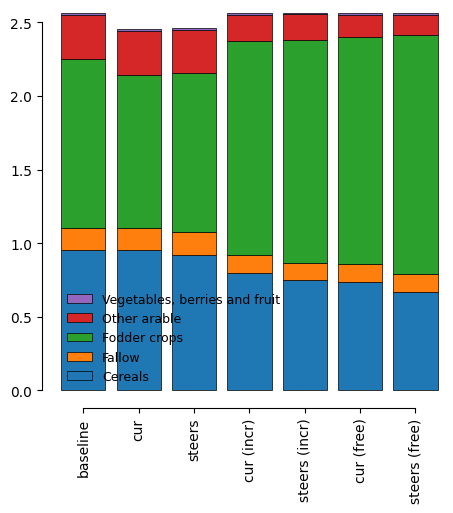

In [8]:
fig, ax = plt.subplots(figsize=(5,5))
plot_data = (
    session.get_attr('c','area',{'crop':['land_use','crop_group2']})
    .droplevel('year')
    .loc[:,'cropland']
)/1000000
cm.plot.bar(
    plot_data,
    ax=ax,
    sort_xlabels=False,
    sort_groups=False
)

In [12]:
session.get_attr('c','area',{'crop':'land_use'}).loc[:,'semi-natural grasslands']/1000000

scn            year
baseline       0       0.449155
cur            0       0.660156
steers         0       0.802964
cur (incr)     0       1.920826
steers (incr)  0       2.106910
cur (free)     0       2.630885
steers (free)  0       2.846062
Name: semi-natural grasslands, dtype: float64

(<Axes: >, [<Axes: label='inset_axes'>])

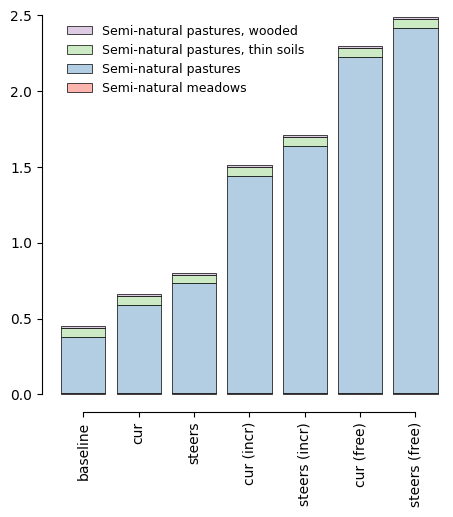

In [10]:
fig, ax = plt.subplots(figsize=(5,5))
plot_data = (
    session.get_attr('c','area',{'crop':['land_use',None]})
    .droplevel('year')
    .loc[:,'semi-natural grasslands']
)/1000000
cm.plot.bar(
    plot_data,
    ax=ax,
    sort_xlabels=False,
    sort_groups=False,
    cmap='Pastel1'
)

## Plot results

In [11]:
# Common style for plots
bar_style = {
    'cmap' : 'Pastel1',
    'edgecolor' : 'grey',
    'bar_width' : 0.6
}

bar_style_one = {
    'color' : 'lightgrey',
    'edgecolor' : 'grey'
}

map_style = {
    'cmap' : 'YlOrBr',
    'edgecolor' : 'grey'
}

map_style_r = map_style.copy()
map_style_r['cmap'] = map_style_r['cmap'] + '_r'

map_style_div = {
    'cmap' : 'BrBG',
    'edgecolor' : 'grey'
}

# Get final iteration of each scenario
scn_final = [(scn, years[-1]) for scn, years in session.scenarios('has output').items()]

### Bar plots: Production and animal heads

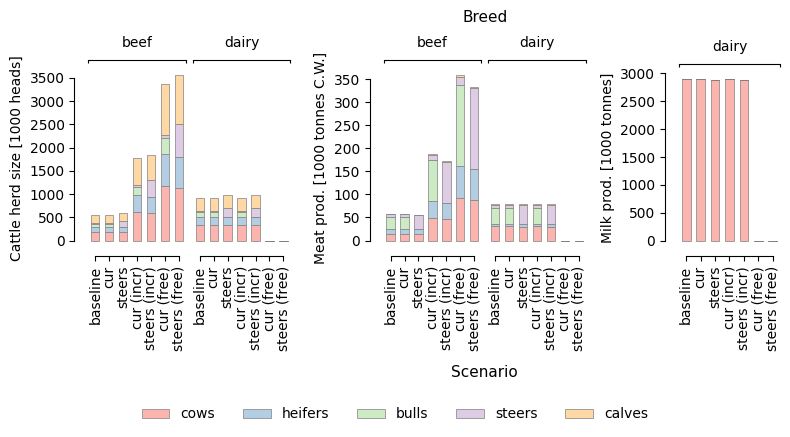

In [12]:
fig, axs = plt.subplots(1,3, figsize=(8,4), width_ratios=(1,1,0.5))

plot_data = (
    session.get_attr('A','heads',['species','animal','breed'])
    .loc[scn_final,:]
    .xs('cattle', level='species', axis=1)
    .stack().droplevel('year')
    .reindex(['cows','heifers','bulls','steers','calves'], level='animal', axis=1)
)/1000

ax=axs[0]
cm.plot.bar(
    plot_data,
    ax=ax, group_levels='breed', sort_xlabels=False, sort_categories=False, **bar_style,
    ylabel='Cattle herd size [1000 heads]', ylabel_fontsize=10
)
ax.get_legend().remove()

plot_data = (
    session.get_attr('A','production',['species','animal','animal_prod', 'breed'])
    .loc[scn_final,:]
    .xs('cattle', level='species', axis=1).droplevel('year')
    .stack()
    .reindex(['cows','heifers','bulls','steers','calves'], level='animal', axis=1)
)/1000000

ax = axs[1]
cm.plot.bar(
    plot_data.xs('meat', level='animal_prod', axis=1),
    ax=ax, group_levels='breed', sort_xlabels=False, sort_categories=False, **bar_style,
    grouptitle='Breed', xlabel='Scenario', ylabel='Meat prod. [1000 tonnes C.W.]', ylabel_fontsize=10
)
ax.get_legend().remove()

ax = axs[2]
cm.plot.bar(
    plot_data.drop('beef', level='breed').xs('milk', level='animal_prod', axis=1).reindex(plot_data.columns.unique('animal'), axis=1),
    ax=ax, group_levels='breed', sort_xlabels=False, sort_categories=False, **bar_style,
    ylabel='Milk prod. [1000 tonnes]', ylabel_fontsize=10
)
ax.get_legend().remove()

fig.legend(*axs[0].get_legend_handles_labels(), loc='upper center', bbox_to_anchor=(0.5,0), ncol=5, frameon=False)
plt.tight_layout()
plt.show()

In [13]:
plot_data = pd.concat([
    session.get_attr('c','area',{'crop':'land_use'}).loc[:,'semi-natural grasslands'].rename('SNG')/1000000,
    cm.get_GHG(session).sum(axis=1).rename('GHG')/1000000000
], axis=1).set_index('SNG', append=True)['GHG'].unstack('scn').droplevel('year')

In [14]:
plot_data

scn,baseline,cur,cur (free),cur (incr),steers,steers (free),steers (incr)
SNG,,,,,,,
0.449155,9.180706,NaN,NaN,NaN,NaN,NaN,NaN
0.660156,NaN,9.273372,NaN,NaN,NaN,NaN,NaN
0.802964,NaN,NaN,NaN,NaN,9.631626,NaN,NaN
1.510011,NaN,NaN,NaN,12.979118,NaN,NaN,NaN
1.707637,NaN,NaN,NaN,NaN,NaN,NaN,13.430583
2.296586,NaN,NaN,14.655697,NaN,NaN,NaN,NaN
2.489850,NaN,NaN,NaN,NaN,NaN,15.210468,NaN


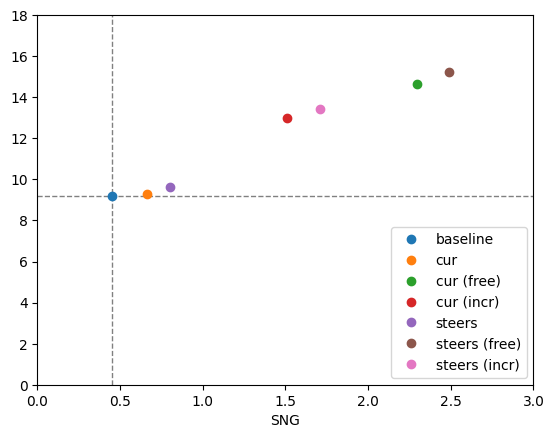

In [15]:
fig,ax = plt.subplots()
ax.axhline(y=plot_data['baseline'].dropna().values, color='grey', linestyle='--', linewidth=1)
ax.axvline(x=plot_data['baseline'].dropna().index.values, color='grey', linestyle='--', linewidth=1)

for col in plot_data.columns:
    plot_data[col].dropna().plot(linestyle='', marker='o')

ax.set_xlim([0,3])
ax.set_ylim([0,18])

ax.legend()
plt.show()

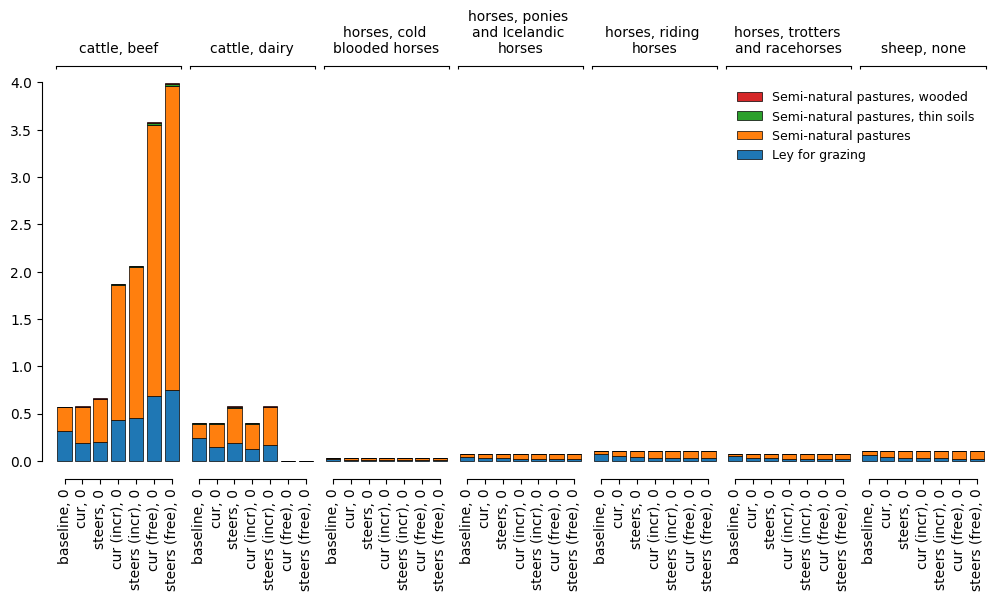

In [16]:
plot_data = (
    session.get_attr('c','production_per_use',['crop','demand'])
    .loc[:,['Ley for grazing', 'Semi-natural pastures', 'Semi-natural pastures, thin soils', 'Semi-natural pastures, wooded']]
)/1000000000
plot_data.columns = pd.MultiIndex.from_tuples(
    [(cr,) + tuple(an.replace('feed (','').replace(')','').split(', ')) for cr, an in plot_data.columns],
    names = ['crop', 'species', 'breed', 'sub_system']
)
plot_data = (
    plot_data.T.groupby(['species','breed','crop']).sum().T
    .stack(['species','breed'])
)
# for sp,br,ss in plot_data.index.droplevel(['scn','year']).unique():
fig,ax = plt.subplots(figsize=(12,5))
d = plot_data#.xs((sp,br,ss), level=('species','breed','sub_system')).dropna(axis=1)
cm.plot.bar(
    d,
    ax=ax,
    group_levels=['species','breed'],
    sort_groups=False,
    sort_xlabels=False,
    sort_categories=False
)
# ax.axhline(d.loc['baseline'].sum(axis=1).iloc[0], c='black', linewidth=0.5, linestyle='--')
plt.show()

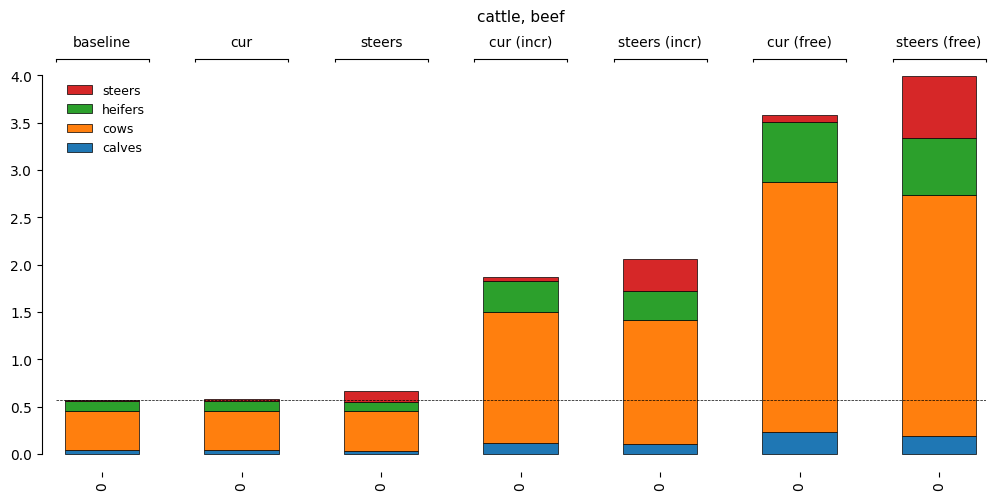

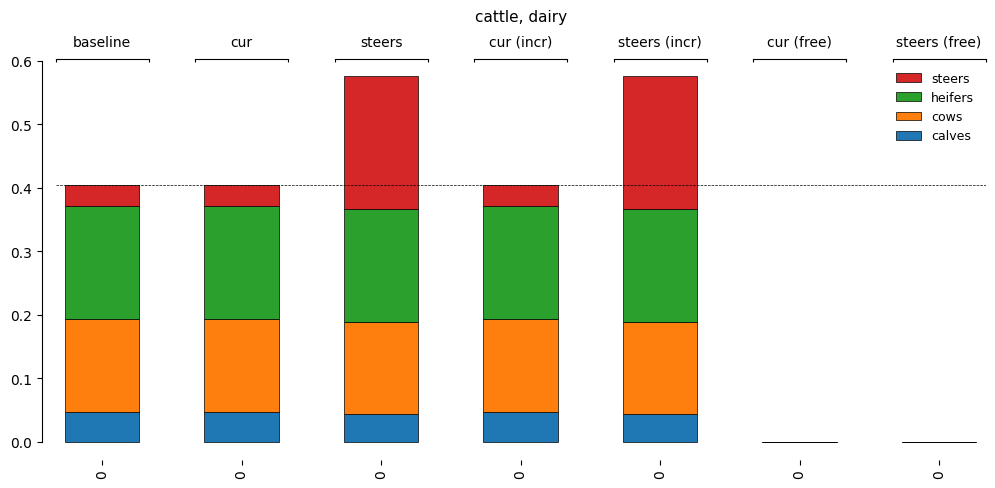

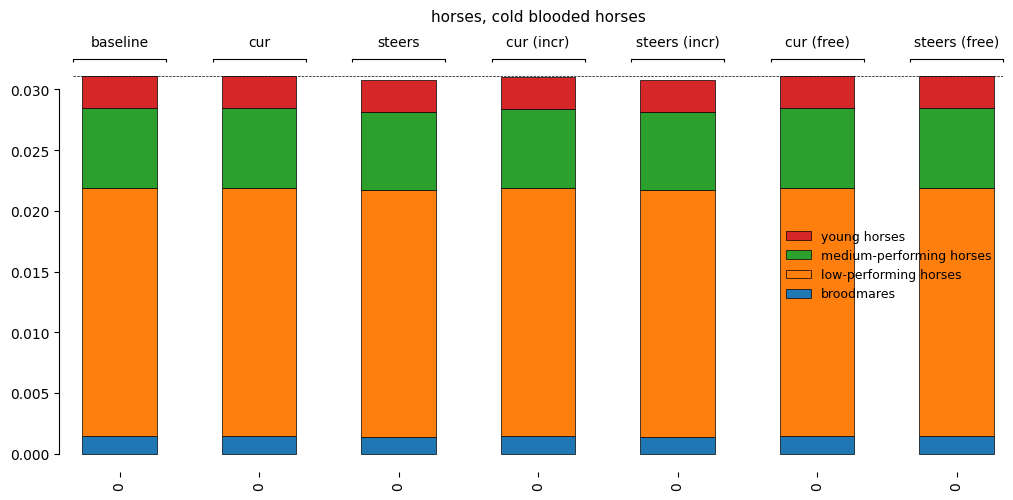

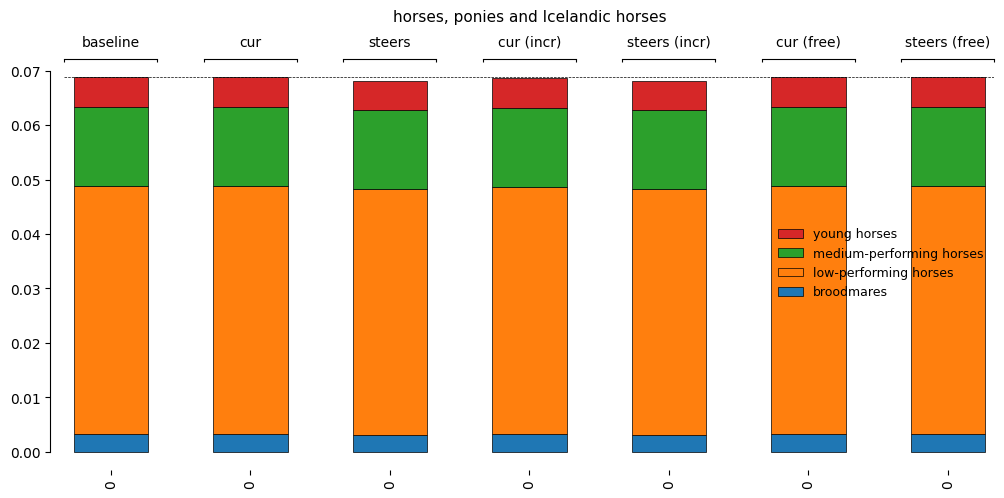

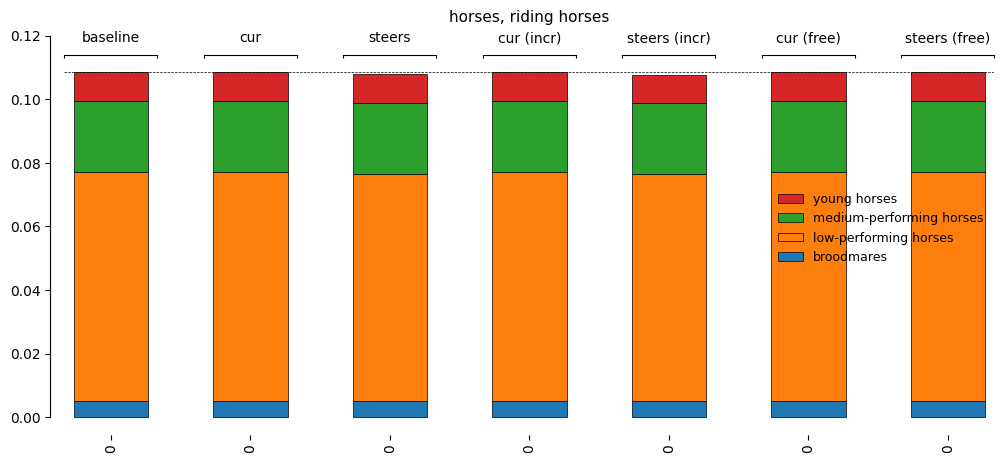

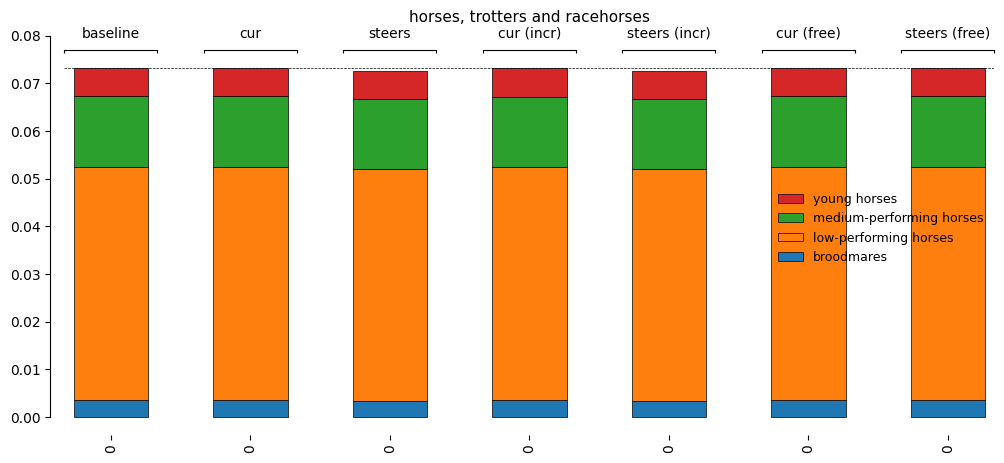

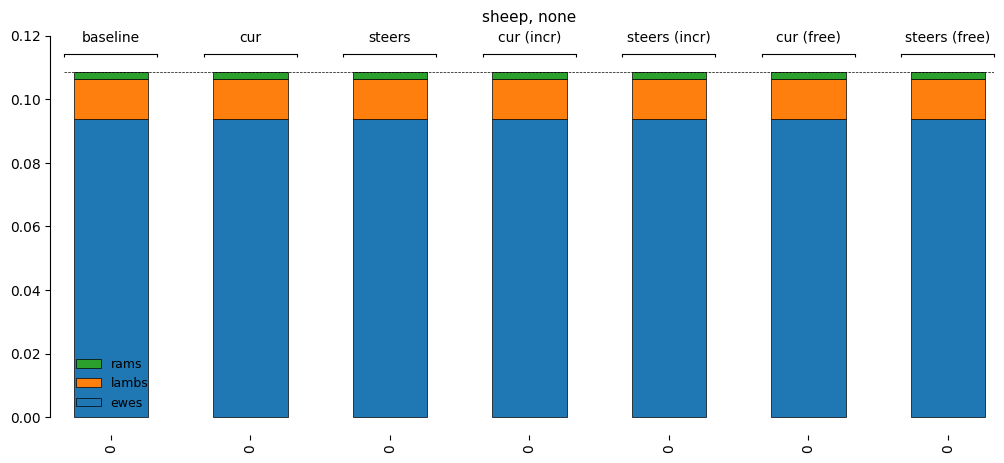

In [17]:
plot_data = (
    session.get_attr('a','feed.crop_prod',['origin','crop_prod','species','breed','animal'])
    .loc[:,'domestic']
    .loc[:,'grazing']
    .stack(['species','breed'])
)/1000000000
for sp,br in plot_data.index.droplevel(['scn','year']).unique():
    fig,ax = plt.subplots(figsize=(12,5))
    d = plot_data.xs((sp,br), level=('species','breed')).dropna(axis=1)
    cm.plot.bar(
        d,
        ax=ax,
        group_levels=['scn'],
        sort_groups=False,
        sort_xlabels=False,
        sort_categories=False,
        grouptitle=f"{sp}, {br}"
    )
    ax.axhline(d.loc['baseline'].sum(axis=1).iloc[0], c='black', linewidth=0.5, linestyle='--')
    plt.show()

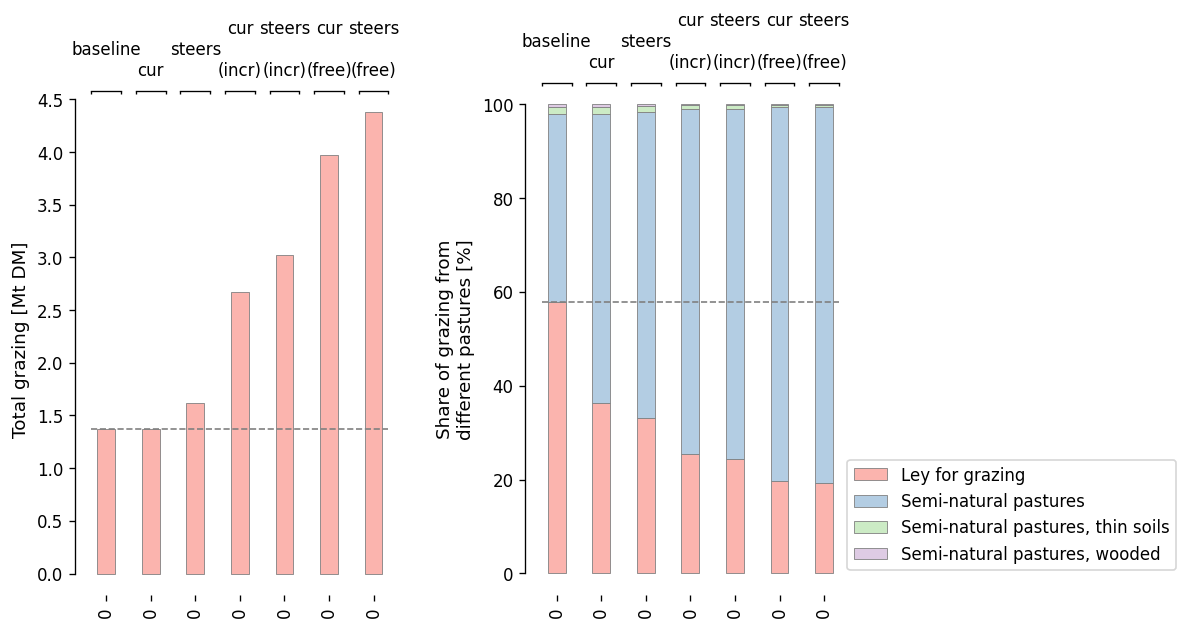

scn            year
baseline       0       42.198908
cur            0       63.753477
steers         0       66.839896
cur (incr)     0       74.505420
steers (incr)  0       75.650324
cur (free)     0       80.353886
steers (free)  0       80.790817
Name: Ley for grazing, dtype: float64

In [20]:
grazing = session.get_attr('C', 'production', ['crop_prod','crop']).loc[:,'grazing']
grazing = grazing.loc[:,grazing.sum()!=0]

plot_data1 = (
    grazing
    # .loc[SCN_NAME]
    # .rename(scn_name_map)
    /1000000000
)

plot_data2 = plot_data1.apply(lambda x: x/x.sum()*100, axis=1)

fig,axs = plt.subplots(1,2, figsize=(10,5), dpi=120)
ax=axs[0]
cm.plot.bar(plot_data1.sum(axis=1), group_levels='scn', **bar_style, ax=ax, sort_xlabels=False, sort_groups=False)
ax.axhline(y=plot_data1.sum(axis=1).loc['baseline'].iloc[0], linestyle='--', linewidth=1, color='grey')
ax.set_ylabel('Total grazing [Mt DM]')
# ax.set_xlabel('')

ax = axs[1]
cm.plot.bar(plot_data2, group_levels='scn', **bar_style, ax=ax, sort_xlabels=False, sort_groups=False, sort_categories=False)
ax.axhline(y=plot_data2.loc['baseline','Ley for grazing'].iloc[0], linestyle='--', linewidth=1, color='grey')
ax.legend(loc='lower left', ncol=1, bbox_to_anchor=(1, 0), fontsize=10)
ax.set_ylabel('Share of grazing from\ndifferent pastures [%]')
# ax.set_xlabel('')

plt.tight_layout()
plt.show()

100-plot_data2.loc[:,'Ley for grazing']

In [21]:
 session.get_attr('geo','x_crops', scn='baseline').iloc[0].loc[['Semi-natural pastures']].sum()/1000*3

1101.6529276240124

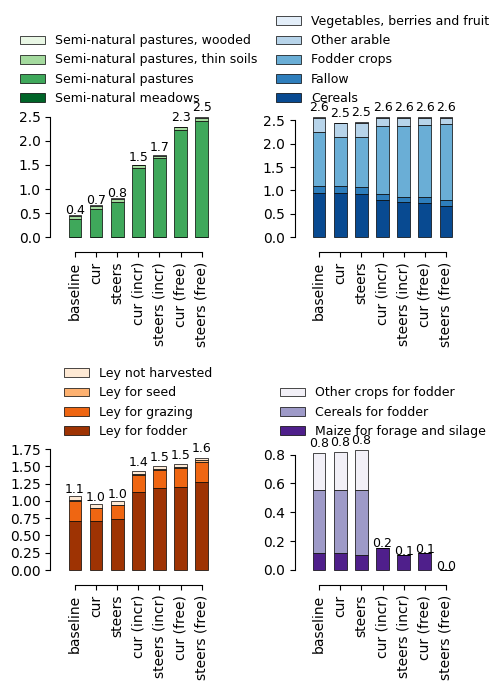

In [22]:
fig, axs = plt.subplots(2,2, figsize=(5,7), width_ratios=(1,1))
axs = axs.flatten()

ax = axs[0]
plot_data = (
    session.get_attr('c','area',{'crop':['land_use',None]})
    .loc[scn_final,:]
    .droplevel('year')
    .loc[:,'semi-natural grasslands']
)/1000000
cm.plot.bar(plot_data, ax=ax, bar_width=0.6, sort_xlabels=False, cmap='Greens')
for x,y in enumerate(plot_data.sum(axis=1)):
    ax.text(x=x+0.5, y=y*1.05, s=str(round(y,1)), ha='center', size=9)

ax=axs[1]
plot_data = (
    session.get_attr('c','area',{'crop':['land_use','crop_group2']})
    .loc[scn_final,:]
    .droplevel('year')
    .loc[:,'cropland']
)/1000000
cm.plot.bar(plot_data, ax=ax, bar_width=0.6, sort_xlabels=False, cmap='Blues')
for x,y in enumerate(plot_data.sum(axis=1)):
    ax.text(x=x+0.5, y=y*1.05, s=str(round(y,1)), ha='center', size=9)

ax=axs[2]
plot_data = (
    session.get_attr('c','area',{'crop':['crop_group',None]})
    .loc[scn_final,:]
    .droplevel('year')
    .loc[:,'Ley']
)/1000000
cm.plot.bar(plot_data, ax=ax, bar_width=0.6, sort_xlabels=False, cmap='Oranges')
for x,y in enumerate(plot_data.sum(axis=1)):
    ax.text(x=x+0.5, y=y*1.05, s=str(round(y,1)), ha='center', size=9)

ax=axs[3]
plot_data = (
    session.get_attr('c','area',{'crop':[None]})
    .loc[scn_final,:]
    .droplevel('year')
    .loc[:,['Maize for forage and silage', 'Cereals for fodder', 'Other crops for fodder']]
)/100000
cm.plot.bar(plot_data, ax=ax, bar_width=0.6, sort_xlabels=False, cmap='Purples')
for x,y in enumerate(plot_data.sum(axis=1)):
    ax.text(x=x+0.5, y=y*1.05, s=str(round(y,1)), ha='center', size=9)

for ax in axs.flatten():
    ax.legend(loc='lower center', bbox_to_anchor=(0.5,1), frameon=False, ncol=1, fontsize=9, reverse=True)

plt.tight_layout()
plt.show()

### Bar plots: GHG and land use

### Maps: Land use and cattle numbers

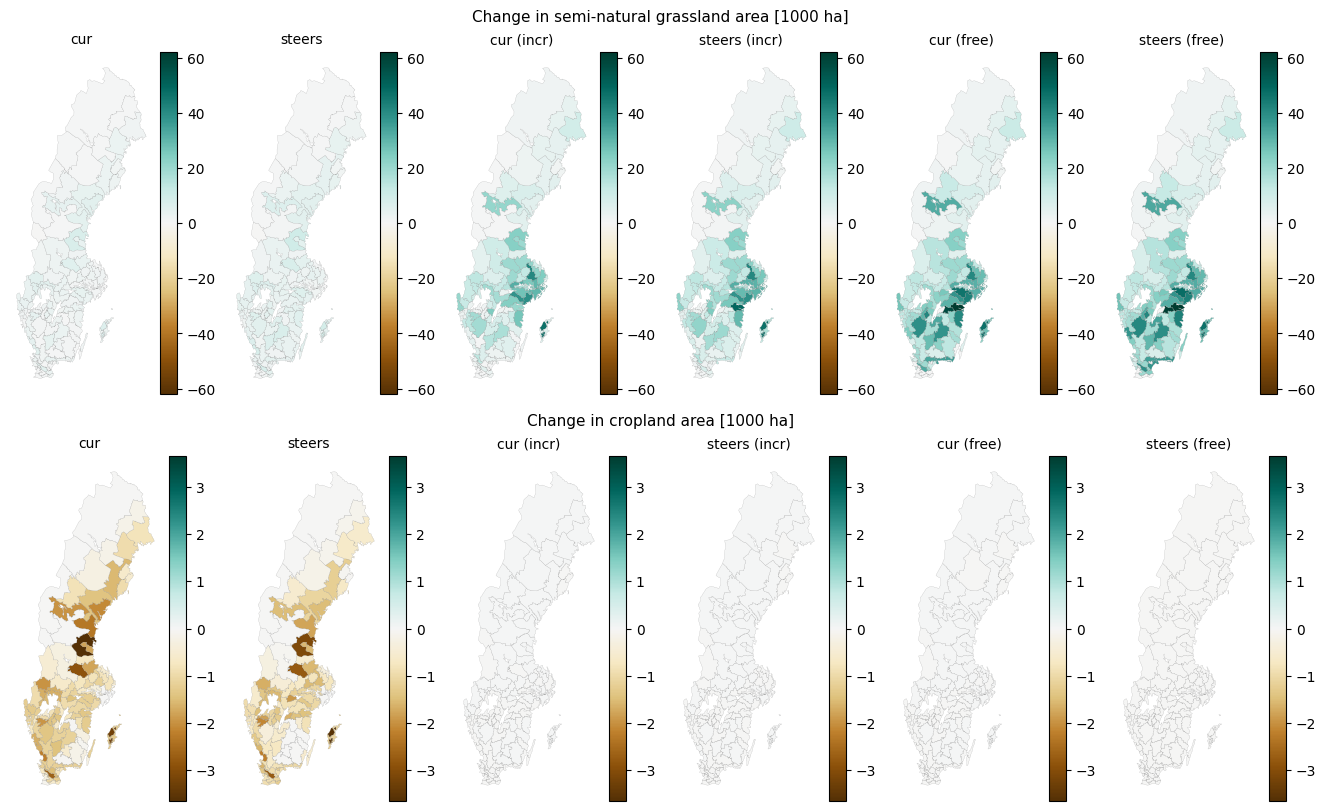

In [29]:
plot_data = (
    session.get_attr('c','area',{'crop':'land_use', 'region':None})
    .loc[scn_final,:]
    .transform(lambda x: x.sub(x.loc[('baseline','0')],axis=1))
    .drop(('baseline','0'))
    .droplevel('year')
)/1000


n_scn = len(plot_data)
lims = plot_data.T.abs().groupby('land_use').max().max(axis=1)

# fig,axs = plot.subplots(plot_data.T.drop('greenhouse'),
#                         size=(2.5,4), columns='scn', index='land_use', title_fontsize=11,
#                         plot_fn=plot.map_from_series,
#                         cmap_zero_midpoint=False, **map_style_div, vmax=8, vmin=-8)
# for ax in axs.flatten():
#     ax.axis('off')
# plt.tight_layout()
# plt.show()

fig = plt.figure(layout='constrained', figsize=(2.2*n_scn, 8))
subfigs = fig.subfigures(2, 1, wspace=0.07)

# Semi-natural grasslands
axs1 = subfigs[0].subplots(1,n_scn)
for n, scn in enumerate(plot_data.index):
    ax = axs1[n]
    cm.plot.map_from_series(
        plot_data.loc[scn,'semi-natural grasslands'],
        ax = ax,
        vmin=-lims.loc['semi-natural grasslands'],
        # cmap_zero_midpoint='shrink',
        vmax=lims.loc['semi-natural grasslands'],
        **map_style_div
    )
    ax.set_title(scn, size=10)
    ax.axis('off')
subfigs[0].suptitle('Change in semi-natural grassland area [1000 ha]', size=11)

# Cropland
axs2 = subfigs[1].subplots(1,n_scn)
# fig, axs = plt.subplots(1,n_scn, figsize=(2.2*n_scn,4))
for n, scn in enumerate(plot_data.index):
    ax = axs2[n]
    cm.plot.map_from_series(
        plot_data.loc[scn,'cropland'],
        ax = ax,
        vmin=-lims.loc['cropland'],
        # cmap_zero_midpoint='shrink',
        vmax=lims.loc['cropland'],
        **map_style_div
    )
    ax.set_title(scn, size=10)
    ax.axis('off')
subfigs[1].suptitle('Change in cropland area [1000 ha]', size=11)
# fig.tight_layout()
plt.show()

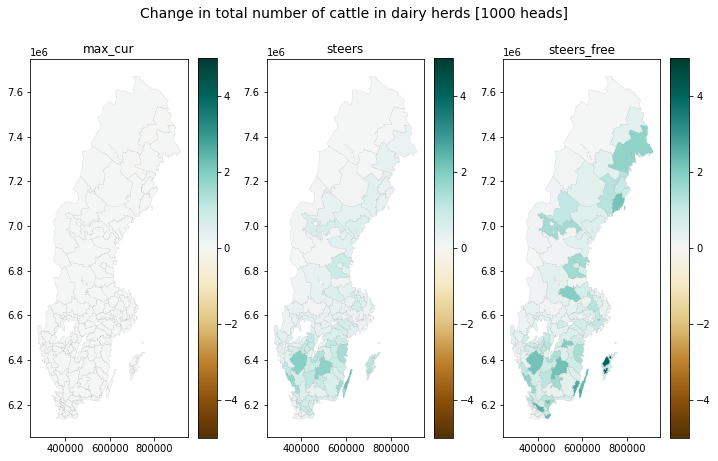

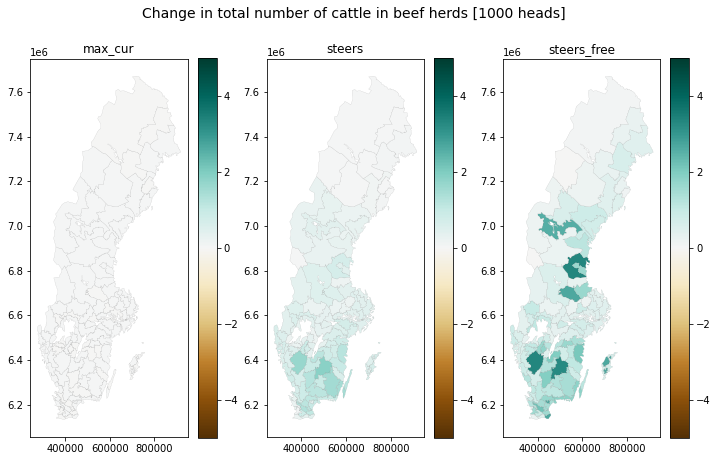

In [22]:
n_scn = len(scenarios)-1
fig, axs = plt.subplots(1,n_scn, figsize=(4*n_scn,7))
n=0
for scn in list(scenarios.keys())[1:]:
    plot_data = (
        output.loc[(scn,year),'ani'].heads.xs(('cattle','dairy'), axis=1).sum(axis=1) -
        output.loc[('baseline',year),'ani'].heads.xs(('cattle','dairy'), axis=1).sum(axis=1)
    )/1000
    ax = axs[n]
    plot.map_from_series(
        plot_data,
        ax = ax,
        vmin=-5,
        vmax=5,
        **map_style_div
    )
    ax.set_title(scn)
    n += 1
plt.suptitle('Change in total number of cattle in dairy herds [1000 heads]', size=14)
plt.show()

fig, axs = plt.subplots(1,n_scn, figsize=(4*n_scn,7))
n=0
for scn in list(scenarios.keys())[1:]:
    plot_data = (
        output.loc[(scn,year),'ani'].heads.xs(('cattle','beef'), axis=1).sum(axis=1) -
        output.loc[('baseline',year),'ani'].heads.xs(('cattle','beef'), axis=1).sum(axis=1)
    )/1000
    ax = axs[n]
    plot.map_from_series(
        plot_data,
        ax = ax,
        vmin=-5,
        vmax=5,
        **map_style_div
    )
    ax.set_title(scn)
    n += 1
plt.suptitle('Change in total number of cattle in beef herds [1000 heads]', size=14)
plt.show()



### Feed rations

In [57]:
feed_rations = (
    (
        output.loc[('baseline',year),'ani'].feed.consumption.sum().groupby(['species','breed','animal','feed']).sum() /
        output.loc[('baseline',year),'ani'].heads.sum().groupby(['species','breed','animal']).sum()
    )
    .unstack(['species','breed','animal'])
    .loc[:,'cattle']
    .dropna(how='all')
    .dropna(how='all', axis=1)
)

feed_rations.to_clipboard()
feed_rations

breed                               beef                           \
animal                             bulls      calves         cows   
feed                                                                
barley                        732.466575    0.000000     0.000000   
broad beans                    60.671369    0.000000     0.000000   
grazing                         0.000000  441.759559  2001.138084   
ley silage, 1st cut          2722.415598    0.000000     0.000000   
ley silage, regrowth            0.000000  999.717284   676.978922   
luzern meal                     0.310046    0.000000     0.000000   
maize                           1.036433    0.000000     0.000000   
maize silage                  147.378130    0.000000     0.000000   
minerals                        5.307731    0.000000     0.000000   
oats                          151.370789    0.000000     0.000000   
other silage                    0.000000    0.000000   700.531662   
palm kernel expeller            3.981597    0.000000     0.000000   
peas                           62.862692    0.000000     0.000000   
potatoe protein                 0.034450    0.000000     0.000000   
rapeseed                       17.445274    0.000000     0.000000   
rapeseed meal                  13.881758    0.000000     0.000000   
rye                             0.000000    0.000000     0.000000   
soybean meal                    5.115897    0.000000     0.000000   
soybeans                        2.013668    0.000000     0.000000   
straw                           0.000000    0.000000   700.531662   
sugar beet molasses             2.884709    0.000000     0.000000   
sugar beet pulp                 5.192475    0.000000     0.000000   
sunflower seed meal             0.499998    0.000000     0.000000   
triticale                     277.949303    0.000000     0.000000   
vegetable oils                  2.850956    0.000000     0.000000   
wheat                         362.280964    0.000000     0.000000   
wheat bran                     11.685997    0.000000     0.000000   
wheat distillers grain, dry     4.905483    0.000000     0.000000   

breed                                                        dairy  \
animal                           heifers       steers        bulls   
feed                                                                 
barley                          0.000000     0.000000   425.235617   
broad beans                     0.000000     0.000000    33.656268   
grazing                       895.345250   914.838488     0.000000   
ley silage, 1st cut             0.000000     0.000000  1924.021225   
ley silage, regrowth         2026.197517  2070.311393     0.000000   
luzern meal                     0.000000     0.000000     0.268115   
maize                           0.000000     0.000000     0.896264   
maize silage                    0.000000     0.000000   123.104324   
minerals                        0.000000     0.000000     4.589906   
oats                            0.000000     0.000000    87.878755   
other silage                    0.000000     0.000000     0.000000   
palm kernel expeller            0.000000     0.000000     3.443121   
peas                            0.000000     0.000000    34.544973   
potatoe protein                 0.000000     0.000000     0.029791   
rapeseed                        0.000000     0.000000    15.085951   
rapeseed meal                   0.000000     0.000000    12.004370   
rye                             0.000000     0.000000     0.000000   
soybean meal                    0.000000     0.000000     4.424016   
soybeans                        0.000000     0.000000     1.741337   
straw                           0.000000     0.000000     0.000000   
sugar beet molasses             0.000000     0.000000     2.494577   
sugar beet pulp                 0.000000     0.000000     4.490238   
sunflower seed meal             0.000000     0.000000     0.432377   
triticale                       0.000000